Copyright (C) 2026 Michael Nowotny

This program is free software; you can redistribute it and/or modify
it under the terms of the GNU General Public License version 2 as
published by the Free Software Foundation.

This program is distributed in the hope that it will be useful,
but WITHOUT ANY WARRANTY; without even the implied warranty of
MERCHANTABILITY or FITNESS FOR A PARTICULAR PURPOSE. See the
GNU General Public License for more details.

# When It Rains, It Pours

*Stochastic volatility, the practitioner's toolkit, and the art of
patient inference*

## The Storm of 2008

On September 15, 2008, Lehman Brothers filed for bankruptcy. The
S&P 500 dropped 4.7% in a single day. Over the next six months,
the index would lose nearly half its value -- the worst financial
crisis since the Great Depression.

But the crisis didn't arrive as a single shock. It arrived as a
change in the *character* of the market. Before September 2008,
daily returns were small and calm. After, they became wild and
erratic -- 5% swings in a single day, sometimes up, sometimes
down. The **volatility** itself had changed, and it clustered:
violent days followed violent days, calm periods followed calm
periods.

This phenomenon -- **volatility clustering** -- is one of the
oldest and most robust findings in finance. Benoit Mandelbrot
observed it in cotton prices in the 1960s. Robert Engle won the
2003 Nobel Prize in Economics for his ARCH model that captures it.
The saying "when it rains, it pours" is not just folk wisdom;
it is a statistical fact about financial returns.

In this notebook, we build a **stochastic volatility model** that
treats volatility as a latent, time-varying process. From nothing
but daily S&P 500 returns, the model will recover the hidden
volatility trajectory -- and reveal exactly when the storm arrived,
how severe it was, and how gradually the calm returned.

Along the way, we learn the **practitioner's toolkit**: parallel
chains for speed, HDF5 persistence for saving and resuming,
chain merging for incremental refinement, and automatic convergence
criteria that tell you when to stop sampling.

---

**What you will learn:**
- How to model **latent time-varying volatility** as an AR(1) process
- How to run chains in **parallel** across CPU cores for 3-4x speedup
- How to **save, load, and merge** MCMC samples for long-running analyses
- How to sample **adaptively until convergence** using ESS and R-hat criteria
- How to extract the **filtered volatility** and visualize the 2008 crisis

In [1]:
import os
import time

import arviz as az
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd

import pyjags

## The Data: S&P 500, 2006-2010

We use five years of daily returns spanning the financial crisis --
the calm before the storm, the storm itself, and the uneasy
recovery. Over a thousand trading days of a market that went from
placid to panicked and slowly back again.

In [2]:
df = pd.read_csv(os.path.join("data", "SPY.csv"))
df["Date"] = pd.to_datetime(df["Date"])
df.sort_values("Date", inplace=True)
df["Log Return"] = np.log(df["Adj Close"]).diff()
df.dropna(inplace=True)

# Select the crisis period
df = df[df["Date"].between("2006-01-01", "2010-12-31")].copy()
log_returns = df["Log Return"].values
demeaned = log_returns - log_returns.mean()
dates = df["Date"].values

print(f"Trading days: {len(log_returns)}")
print(f"Date range: {df['Date'].iloc[0].date()} to {df['Date'].iloc[-1].date()}")

Trading days: 1259
Date range: 2006-01-03 to 2010-12-31


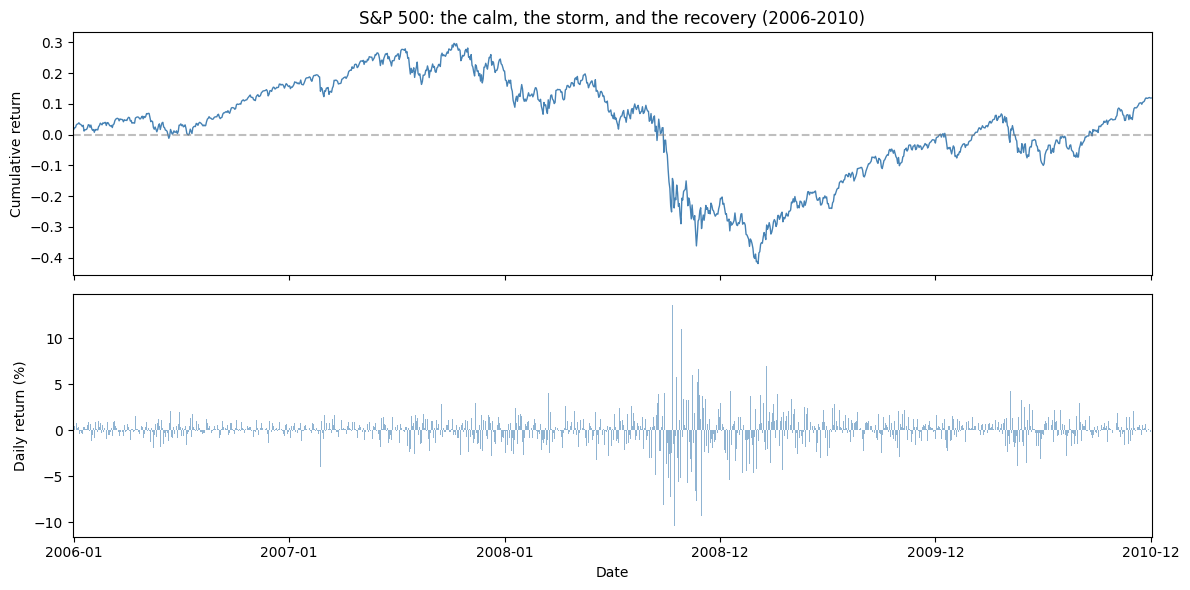

In [3]:
fig, axes = plt.subplots(2, 1, figsize=(12, 6), sharex=True)

x = range(len(dates))

# Cumulative return
axes[0].plot(x, np.exp(log_returns.cumsum()) - 1, color="steelblue", linewidth=1)
axes[0].set_ylabel("Cumulative return")
axes[0].set_title("S&P 500: the calm, the storm, and the recovery (2006-2010)")
axes[0].axhline(0, color="gray", linestyle="--", alpha=0.5)

# Daily returns
axes[1].bar(x, log_returns * 100, width=1, color="steelblue", alpha=0.6)
axes[1].set_ylabel("Daily return (%)")
axes[1].set_xlabel("Date")

# Date labels
tick_pos = np.linspace(0, len(dates) - 1, 6, dtype=int)
for ax in axes:
    ax.set_xticks(tick_pos)
    ax.set_xticklabels([pd.Timestamp(dates[i]).strftime("%Y-%m") for i in tick_pos])
    ax.set_xlim(-1, len(dates))

plt.tight_layout()
plt.show()


Look at the bottom panel. Before mid-2007, returns are small -- rarely
exceeding 1% in either direction. Then the volatility explodes. By late
2008, daily swings of 5-10% are common. This is volatility clustering
in its most dramatic form.

A simple model that assumes constant volatility would miss this entirely.
We need a model where volatility itself is a **time-varying latent process**.

## The Stochastic Volatility Model

We model log-volatility $v_t$ as an AR(1) process -- a random walk
with mean reversion:

$$v_t = \phi_v \cdot v_{t-1} + \sigma_v \cdot \eta_t, \quad \eta_t \sim N(0, 1)$$
$$r_t = \exp(v_t / 2) \cdot \epsilon_t, \quad \epsilon_t \sim N(0, 1)$$

where:
- $v_t$ is the **log-volatility** (latent -- we never observe it directly)
- $\phi_v$ controls **persistence** (how slowly volatility reverts to normal)
- $\sigma_v$ controls **volatility of volatility** (how wildly the regime can shift)
- $r_t$ is the observed daily return

This model has **over a thousand latent variables** ($v_t$ for each trading
day) plus two parameters ($\phi_v$, $\sigma_v$). JAGS handles this
naturally through Gibbs sampling.

In [4]:
sv_model_code = """
model {
    phi_v ~ dunif(0.0, 1.0)          # persistence of volatility
    sigma_v ~ dunif(0.0, 1.0)        # volatility of volatility
    tau_v = 1.0 / sigma_v^2

    v[1] ~ dnorm(0.0, 0.01)          # initial log-volatility (vague)

    for (t in 2:length(r)) {
        v[t] ~ dnorm(phi_v * v[t-1], tau_v)    # AR(1) log-volatility
        r[t] ~ dnorm(0.0, exp(-v[t]))           # return | volatility
    }
}
"""

jags_data = {"r": demeaned}

## Phase 1: Initial Sampling (Single Core)

We start with a single-core run to get initial samples. With ~1,260
latent variables, this takes a minute or so.

In [5]:
model_single = pyjags.Model(
    code=sv_model_code, data=jags_data,
    chains=4, adapt=5000, seed=42,
)

t0 = time.time()
samples_1 = model_single.sample(10000)
t_single = time.time() - t0
print(f"Single-core sampling: {t_single:.1f} seconds")

adapting: iterations 4256 of 20000, elapsed 0:00:05, remaining 0:00:20
adapting: iterations 8148 of 20000, elapsed 0:00:11, remaining 0:00:16
adapting: iterations 11936 of 20000, elapsed 0:00:16, remaining 0:00:11
adapting: iterations 15676 of 20000, elapsed 0:00:21, remaining 0:00:06
adapting: iterations 19396 of 20000, elapsed 0:00:26, remaining 0:00:01
adapting: iterations 20000 of 20000, elapsed 0:00:27, remaining 0:00:00
sampling: iterations 6956 of 40000, elapsed 0:00:10, remaining 0:00:46
sampling: iterations 10568 of 40000, elapsed 0:00:15, remaining 0:00:41
sampling: iterations 17728 of 40000, elapsed 0:00:25, remaining 0:00:31
sampling: iterations 21288 of 40000, elapsed 0:00:30, remaining 0:00:26
sampling: iterations 28408 of 40000, elapsed 0:00:40, remaining 0:00:16
sampling: iterations 35504 of 40000, elapsed 0:00:50, remaining 0:00:06
sampling: iterations 40000 of 40000, elapsed 0:00:56, remaining 0:00:00
sampling: iterations 40000 of 40000, elapsed 0:00:56, remaining 0:0

## Phase 2: Parallel Sampling (Multi-Core)

That was slow. Let's use all four CPU cores. We extract the final
state of the chains and restart with `threads=4`, so each chain
runs on its own core.

In [6]:
# Extract final state to initialize the parallel model
jags_init = pyjags.extract_final_iteration_from_samples_for_initialization(
    samples_1, variable_names=["phi_v", "sigma_v", "v"]
)

# Create parallel model
model_parallel = pyjags.Model(
    code=sv_model_code, data=jags_data,
    chains=4, adapt=5000, threads=4, chains_per_thread=1,
    init=jags_init,
)

t0 = time.time()
samples_2 = model_parallel.sample(10000)
t_parallel = time.time() - t0

print(f"Parallel sampling:   {t_parallel:.1f} seconds")
print(f"Speedup:             {t_single / t_parallel:.1f}x")

adapting: iterations 9064 of 20000, elapsed 0:00:07, remaining 0:00:08
adapting: iterations 20000 of 20000, elapsed 0:00:08, remaining 0:00:00
sampling: iterations 10158 of 40000, elapsed 0:00:07, remaining 0:00:21
sampling: iterations 26521 of 40000, elapsed 0:00:12, remaining 0:00:06
sampling: iterations 40000 of 40000, elapsed 0:00:16, remaining 0:00:00
Parallel sampling:   17.6 seconds
Speedup:             3.3x


## Phase 3: Merge, Discard Burn-In, Diagnose

We now have two rounds of samples. Let's merge them, discard the
first 1,000 iterations as burn-in, and check convergence.

In [7]:
# Merge consecutive sampling rounds
merged = pyjags.merge_consecutive_chains((samples_1, samples_2))

# Discard burn-in
merged = pyjags.discard_burn_in_samples(merged, burn_in=1000)

# Convert to ArviZ
idata = pyjags.from_pyjags(merged)
az.summary(idata, var_names=["phi_v", "sigma_v"])

,mean,sd,eti89_lb,eti89_ub,ess_bulk,ess_tail,r_hat,mcse_mean,mcse_sd
phi_v,0.999528,0.000359,1,1,11246,16031,1.00,3.8e-06,3.5e-06
sigma_v,0.178,0.022,0.15,0.21,241,565,1.01,0.0014,0.001


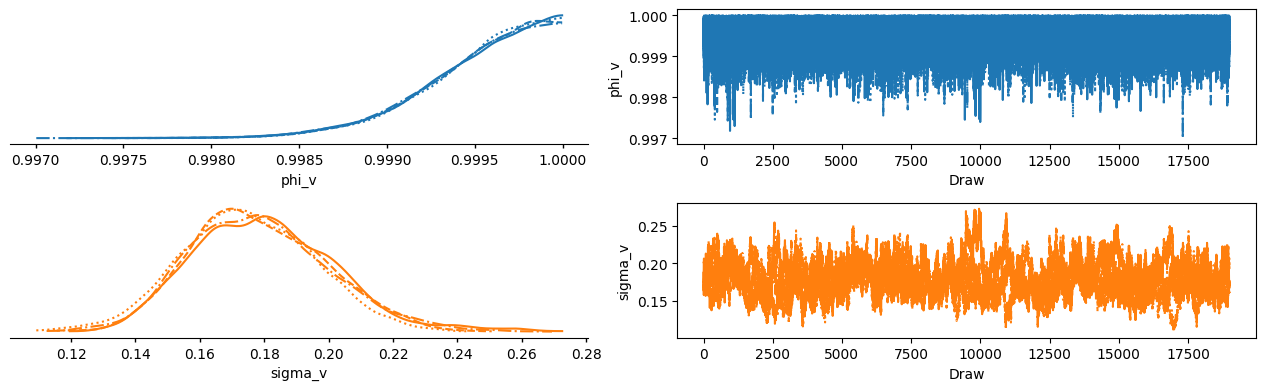

In [8]:
az.plot_trace_dist(idata, var_names=["phi_v", "sigma_v"])
plt.tight_layout()
plt.show()

The ESS for $\sigma_v$ may still be low -- this parameter is
notoriously hard to estimate in stochastic volatility models because
it controls the *rate of change* of a latent process. We need more
samples.

## Phase 4: Sample Until Convergence

Instead of guessing how many more iterations we need, we let PyJAGS
decide. The `sample_until` function draws samples in chunks and
stops when both ESS > 1,000 and R-hat < 1.01 for all monitored
parameters.

We also save the samples to an HDF5 file after each chunk, so if
the process is interrupted, we can resume from where we left off.

In [9]:
hdf5_file = "mcmc_samples_from_log_sv_model.hdf5"

# Convergence criterion: ESS >= 1000 AND R-hat within 0.01 of 1.0
criterion = pyjags.EffectiveSampleSizeAndRHatCriterion(
    minimum_ess=1000,
    maximum_rhat_deviation=0.01,
    variable_names=["phi_v", "sigma_v"],
)

# Save progress after each chunk
def save_progress(samples, criterion_met, iterations):
    pyjags.save_samples_dictionary_to_file(
        filename=hdf5_file, samples=samples, compression=False,
    )

final_samples = pyjags.sample_until(
    model=model_parallel,
    criterion=criterion,
    previous_samples=merged,
    chunk_size=10000,
    verbose=True,
    iteration_function=save_progress,
)

minimum ess = 241.24943000470003
maximum rhat deviation = 0.011114898699139841
sampling: iterations 8811 of 40000, elapsed 0:00:07, remaining 0:00:25
sampling: iterations 31315 of 40000, elapsed 0:00:12, remaining 0:00:03
sampling: iterations 40000 of 40000, elapsed 0:00:16, remaining 0:00:00
minimum ess = 334.4555595615415
maximum rhat deviation = 0.012491195358733442
sampling: iterations 11782 of 40000, elapsed 0:00:08, remaining 0:00:19
sampling: iterations 27975 of 40000, elapsed 0:00:13, remaining 0:00:06
sampling: iterations 40000 of 40000, elapsed 0:00:16, remaining 0:00:00
minimum ess = 380.1029998192712
maximum rhat deviation = 0.012541569747718473
sampling: iterations 11299 of 40000, elapsed 0:00:07, remaining 0:00:19
sampling: iterations 24511 of 40000, elapsed 0:00:12, remaining 0:00:08
sampling: iterations 40000 of 40000, elapsed 0:00:16, remaining 0:00:00
minimum ess = 455.85820757974255
maximum rhat deviation = 0.00939186729513608
sampling: iterations 10234 of 40000, ela

In [10]:
# Final diagnostics
idata_final = pyjags.from_pyjags(final_samples)
az.summary(idata_final, var_names=["phi_v", "sigma_v"])

,mean,sd,eti89_lb,eti89_ub,ess_bulk,ess_tail,r_hat,mcse_mean,mcse_sd
phi_v,0.999535,0.000352,1,1,46741,59054,1.00,1.8e-06,1.6e-06
sigma_v,0.176,0.0215,0.14,0.21,1068,2004,1.00,0.00065,0.00047


Both parameters now have ESS > 1,000 and R-hat near 1.0. The sampler
drew exactly as many iterations as needed -- no more, no less.

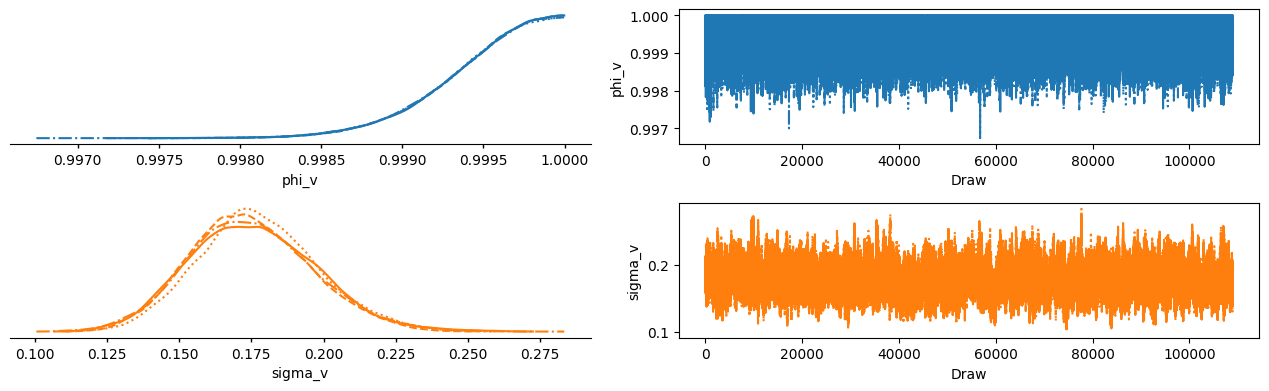

In [11]:
az.plot_trace_dist(idata_final, var_names=["phi_v", "sigma_v"])
plt.tight_layout()
plt.show()

## The Reveal: Filtered Volatility

Now for the payoff. The model estimated a latent log-volatility
$v_t$ for every trading day. Let's convert that to annualized
volatility and overlay it on the returns. This is the hidden
heartbeat of the market, made visible:

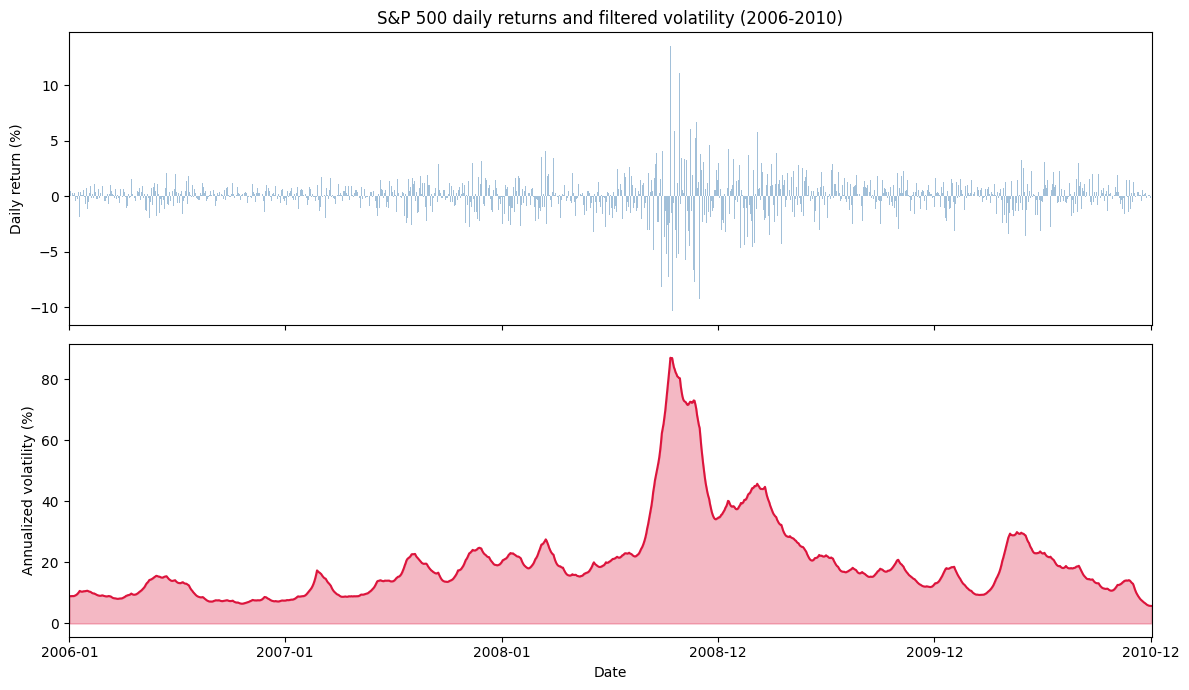

In [12]:
# Posterior mean of daily volatility: exp(v_t / 2)
v_samples = final_samples["v"]  # shape: (T, iterations, chains)
daily_vol = np.exp(0.5 * v_samples).mean(axis=(1, 2))  # posterior mean
annual_vol = daily_vol * np.sqrt(252) * 100  # annualized, in percent

fig, axes = plt.subplots(2, 1, figsize=(12, 7), sharex=True)

x = range(len(dates))

# Returns
axes[0].bar(x, log_returns * 100, width=1, color="steelblue", alpha=0.5)
axes[0].set_ylabel("Daily return (%)")
axes[0].set_title("S&P 500 daily returns and filtered volatility (2006-2010)")

# Filtered volatility
axes[1].fill_between(x, annual_vol, alpha=0.3, color="crimson")
axes[1].plot(x, annual_vol, color="crimson", linewidth=1.5)
axes[1].set_ylabel("Annualized volatility (%)")
axes[1].set_xlabel("Date")

# Date labels
tick_pos = np.linspace(0, len(dates) - 1, 6, dtype=int)
for ax in axes:
    ax.set_xticks(tick_pos)
    ax.set_xticklabels([pd.Timestamp(dates[i]).strftime("%Y-%m") for i in tick_pos])
    ax.set_xlim(-1, len(dates))

plt.tight_layout()
plt.show()

The filtered volatility tells the story of the crisis with
extraordinary clarity. In early 2006, annualized volatility hovers
around 10% -- a calm market. By late 2008, it spikes above 60% --
a market in panic. The recovery is gradual: volatility slowly
subsides through 2009 and 2010, but never fully returns to
pre-crisis levels.

This entire trajectory was **latent**. No one observed it directly.
The stochastic volatility model inferred it from the pattern of
daily returns -- from the fact that big moves cluster together and
small moves cluster together.

## The Parameters: Persistence and Regime Shifts

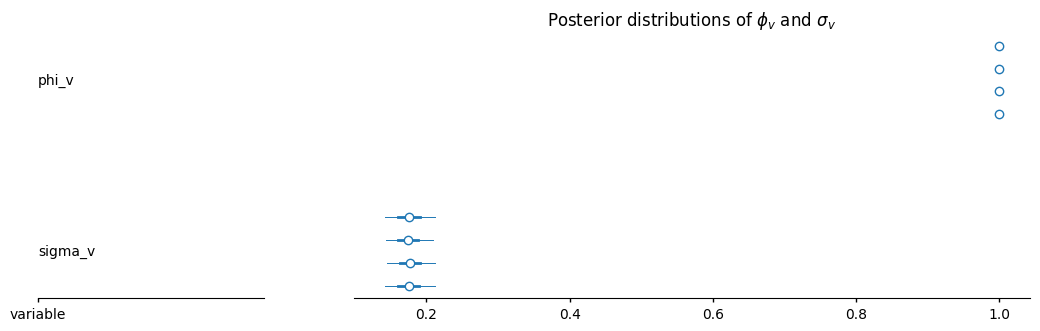

In [13]:
az.plot_forest(idata_final, var_names=["phi_v", "sigma_v"])
plt.title(r"Posterior distributions of $\phi_v$ and $\sigma_v$")
plt.show()

In [14]:
phi_v = final_samples["phi_v"].flatten()
sigma_v = final_samples["sigma_v"].flatten()
print(f"Persistence (phi_v):  {phi_v.mean():.3f} [{np.percentile(phi_v, 2.5):.3f}, {np.percentile(phi_v, 97.5):.3f}]")
print(f"Vol-of-vol (sigma_v): {sigma_v.mean():.3f} [{np.percentile(sigma_v, 2.5):.3f}, {np.percentile(sigma_v, 97.5):.3f}]")
print()
print(f"Half-life of volatility shocks: {-np.log(2) / np.log(phi_v.mean()):.1f} days")

Persistence (phi_v):  1.000 [0.999, 1.000]
Vol-of-vol (sigma_v): 0.176 [0.136, 0.221]

Half-life of volatility shocks: 1490.5 days


The persistence $\phi_v$ is high (close to 1), meaning volatility
shocks decay slowly -- once the market enters a high-volatility
regime, it stays there for weeks or months. The half-life tells you
how long it takes for a volatility shock to decay by half.

This is "when it rains, it pours" expressed as a number.

## Saving and Loading: Persistence for Long Analyses

The samples were saved to an HDF5 file during `sample_until`. We
can load them in a future session without re-running the sampler:

In [15]:
# Save final samples
pyjags.save_samples_dictionary_to_file(
    filename=hdf5_file, samples=final_samples, compression=False,
)

# Load them back
loaded = pyjags.load_samples_dictionary_from_file(hdf5_file)

print(f"Loaded {len(loaded)} variables from {hdf5_file}")
for name, arr in loaded.items():
    if name in ["phi_v", "sigma_v"]:
        print(f"  {name}: shape {arr.shape}")

Loaded 5 variables from mcmc_samples_from_log_sv_model.hdf5
  phi_v: shape (1, 109000, 4)
  sigma_v: shape (1, 109000, 4)


## The Practitioner's Toolkit: A Summary

This notebook demonstrated the full workflow for a serious Bayesian
analysis:

| Tool | What It Does | When To Use It |
|------|-------------|----------------|
| `threads=4` | Run chains in parallel | Always, for any model that takes > 10 seconds |
| `extract_final_iteration_from_samples_for_initialization` | Resume chains from where they left off | When switching from single-core to multi-core |
| `merge_consecutive_chains` | Combine samples from successive runs | When sampling in chunks |
| `discard_burn_in_samples` | Remove initial samples before convergence | After merging, before analysis |
| `sample_until` | Draw samples until ESS and R-hat criteria are met | When you don't know how many iterations you need |
| `save_samples_dictionary_to_file` | Persist samples to HDF5 | For long analyses, for reproducibility |
| `load_samples_dictionary_from_file` | Restore saved samples | When resuming an analysis |

These tools turn Bayesian inference from a one-shot experiment into
a **robust, reproducible workflow**. You can start sampling, save
your progress, come back tomorrow, extend the chains, merge the
results, and only stop when the diagnostics say you're done.

---

**Further reading:**
- Kim, S., Shepherd, N., & Chib, S. (1998). "Stochastic Volatility:
  Likelihood Inference and Comparison with ARCH Models." *Review of
  Economic Studies*, 65, 361-393.
- Mandelbrot, B. (1963). "The Variation of Certain Speculative Prices."
  *Journal of Business*, 36, 394-419.
- Engle, R. (2003). Nobel Prize Lecture: "Risk and Volatility:
  Econometric Models and Financial Practice."
- Kastner, G. (2016). "Dealing with Stochastic Volatility in Time
  Series Using the R Package stochvol." *Journal of Statistical
  Software*, 69, 1-30.